# Project-3: Mortgage Payback Analytics
Predicts borrower outcomes (Default vs. Paidoff) on the Mortgage dataset:
Goal 1 — classify ACTIVE borrowers using full behavioral + origination features
Goal 2 — risk-score NEW customers using origination-time features only
Requirements: pandas, numpy, matplotlib, seaborn, scikit-learn, statsmodels

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

RANDOM_SEED = 2024
np.random.seed(RANDOM_SEED)

## Load the Mortgage file

In [2]:
mortgage = pd.read_csv("Mortgage.csv")
print(mortgage.head())

# Categorical/indicator attribute columns (equivalent of R columns 12,13,14,15,21,22,23)
categorical_cols = [c for c in [
    "REtype_CO_orig_time", "REtype_PU_orig_time", "REtype_SF_orig_time",
    "investor_orig_time", "default_time", "payoff_time", "status_time",
] if c in mortgage.columns]
numerical_attributes = mortgage.drop(columns=categorical_cols)
categorical_attributes = mortgage[categorical_cols]

print(numerical_attributes.head())
print(categorical_attributes.head())
print(numerical_attributes.describe())
print(mortgage.info())

   id  time  orig_time  first_time  mat_time  balance_time   LTV_time  \
0   1    25         -7          25       113      41303.42  24.498336   
1   1    26         -7          25       113      41061.95  24.483867   
2   1    27         -7          25       113      40804.42  24.626795   
3   1    28         -7          25       113      40483.89  24.735883   
4   1    29         -7          25       113      40367.06  24.925476   

   interest_rate_time  hpi_time  gdp_time  ...  REtype_SF_orig_time  \
0                 9.2    226.29  2.899137  ...                    1   
1                 9.2    225.10  2.151365  ...                    1   
2                 9.2    222.39  2.361722  ...                    1   
3                 9.2    219.67  1.229172  ...                    1   
4                 9.2    217.37  1.692969  ...                    1   

   investor_orig_time  balance_orig_time  FICO_orig_time  LTV_orig_time  \
0                   0            45000.0             715   

## Check for missing values

In [3]:
missing_values_df = mortgage.isna().sum().to_frame("Missing_Values")
print(missing_values_df)

# Borrower IDs that have any missing value
borrower_ids_with_missing = mortgage.loc[mortgage.isna().any(axis=1), "id"].unique()
print(borrower_ids_with_missing)

# Inspect IDs with missing LTV_time and whether their origination balance is zero
missing_ids = mortgage.loc[mortgage["LTV_time"].isna(), "id"].unique()
count_table = pd.DataFrame({
    "ID": missing_ids,
    "LTV_time_missing": "Yes",
    "Balance_orig_zero": [
        "Yes" if (mortgage.loc[mortgage["id"] == i, "balance_orig_time"] == 0).any() else "No"
        for i in missing_ids
    ],
})
print(count_table)

# Replace missing LTV_time with zero (these IDs have zero origination balance)
mortgage["LTV_time"] = mortgage["LTV_time"].fillna(0)
print("Remaining missing LTV_time:", mortgage["LTV_time"].isna().sum())

                         Missing_Values
id                                    0
time                                  0
orig_time                             0
first_time                            0
mat_time                              0
balance_time                          0
LTV_time                            270
interest_rate_time                    0
hpi_time                              0
gdp_time                              0
uer_time                              0
REtype_CO_orig_time                   0
REtype_PU_orig_time                   0
REtype_SF_orig_time                   0
investor_orig_time                    0
balance_orig_time                     0
FICO_orig_time                        0
LTV_orig_time                         0
Interest_Rate_orig_time               0
hpi_orig_time                         0
default_time                          0
payoff_time                           0
status_time                           0
[39722 39723 39724 39725 39726 39727 397

## Check for zeros

                         Zeros_Count
id                                 0
time                               0
orig_time                       1040
first_time                         0
mat_time                           0
balance_time                     324
LTV_time                         323
interest_rate_time                25
hpi_time                           0
gdp_time                           0
uer_time                           0
balance_orig_time                270
FICO_orig_time                     0
LTV_orig_time                      0
Interest_Rate_orig_time        89992
hpi_orig_time                      0


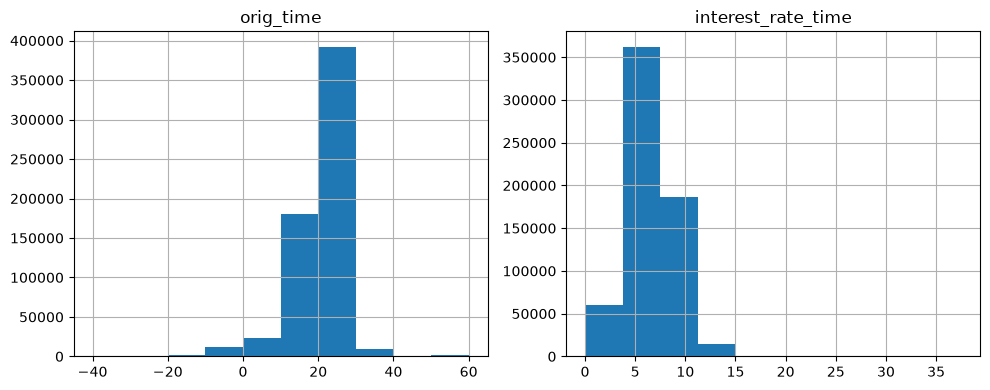

110878    62934.25
110879    62289.25
111606    88192.29
111607    88192.29
111608    88192.29
            ...   
522792    75026.40
522793    74641.17
522794    74216.90
522795    73815.64
522796    73406.43
Name: balance_time, Length: 441, dtype: float64


In [4]:
zeros_df = (numerical_attributes == 0).sum().to_frame("Zeros_Count")
print(zeros_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
mortgage["orig_time"].hist(ax=axes[0])
axes[0].set_title("orig_time")
mortgage["interest_rate_time"].hist(ax=axes[1])
axes[1].set_title("interest_rate_time")
plt.tight_layout()
plt.show()

ids_with_zero_interest = mortgage.loc[mortgage["interest_rate_time"] == 0, "id"]
zero_interest_data = mortgage[mortgage["id"].isin(ids_with_zero_interest)]
print(zero_interest_data["balance_time"])

## Data Transformation

### Transactions per borrower (time-stamp variable)

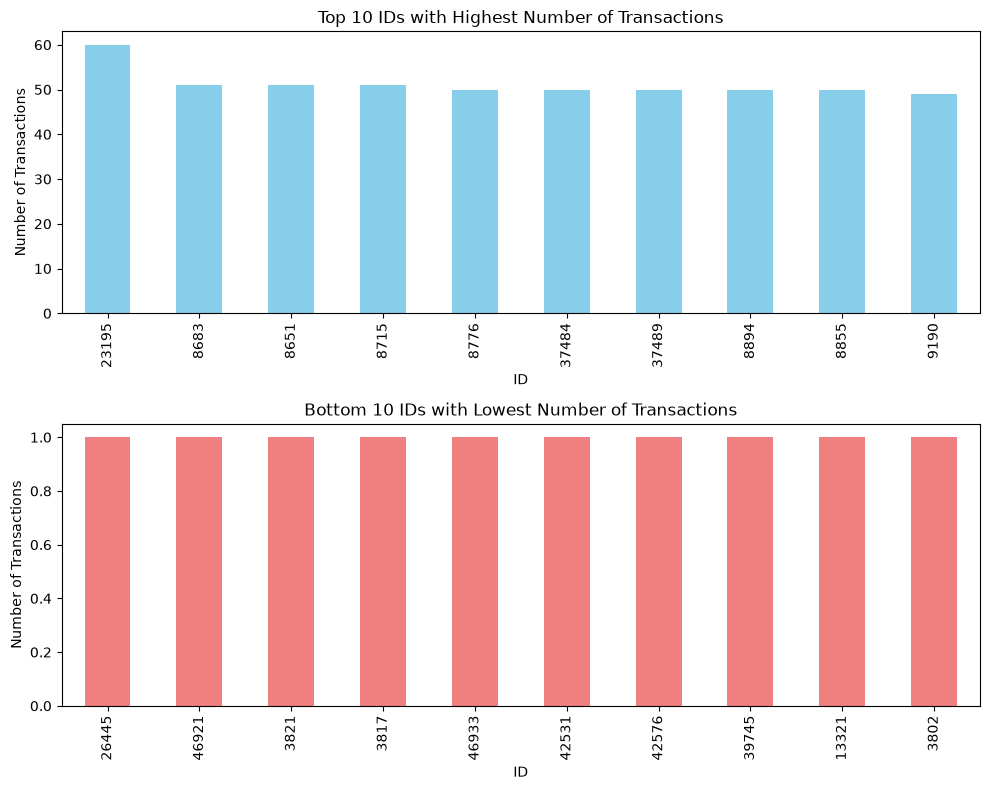

   id  number_of_transactions
0   1                      24
1   2                       2
2   3                       5
3   4                      35
4   5                       3
Rows: 46315
Unique IDs in Mortgage: 46315


In [5]:
transaction_counts = mortgage.groupby("id").size().rename("number_of_transactions")

top_10 = transaction_counts.sort_values(ascending=False).head(10)
bottom_10 = transaction_counts.sort_values().head(10)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
top_10.plot(kind="bar", color="skyblue", ax=axes[0],
            title="Top 10 IDs with Highest Number of Transactions")
bottom_10.plot(kind="bar", color="lightcoral", ax=axes[1],
               title="Bottom 10 IDs with Lowest Number of Transactions")
for ax in axes:
    ax.set_xlabel("ID"); ax.set_ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# Filter out IDs with a single transaction whose status is already resolved (1 or 2)
mortgage["number_of_transactions"] = mortgage.groupby("id")["id"].transform("size")
single_resolved = (
    (mortgage["number_of_transactions"] == 1)
    & mortgage.groupby("id")["status_time"].transform(lambda s: s.isin([1, 2]).any())
)
mortgage = mortgage[~single_resolved].copy()

# One row per unique borrower
mortgage_transformed = (
    mortgage.drop_duplicates(subset="id")[["id", "number_of_transactions"]]
    .reset_index(drop=True)
)
print(mortgage_transformed.head())
print("Rows:", len(mortgage_transformed))
print("Unique IDs in Mortgage:", mortgage["id"].nunique())

### orig_time & first_time

Variance orig_time: 57.970796948102134
Unique first_time: [25 33 26 23 19 20 24 28 32 31 27 29 22 18 21 30 16 17  1  2  6  3  9 10
 11 12 13  5 36 35 34 15 50 51 52 53 54 55 57 56 58 59 60  4 14 46 37 43
 49 38]
Variance first_time: 45.38907117768867


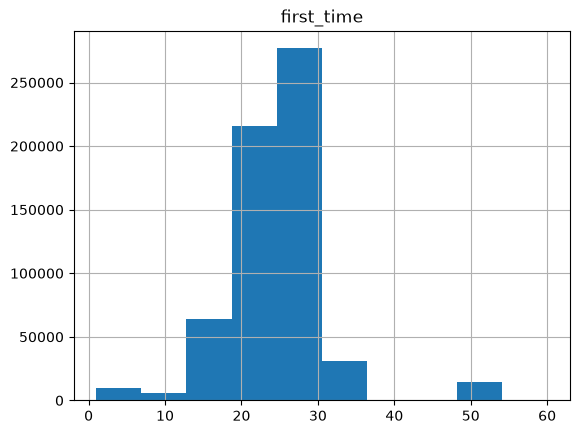

In [6]:
print("Variance orig_time:", mortgage["orig_time"].var())
print("Unique first_time:", mortgage["first_time"].unique())
print("Variance first_time:", mortgage["first_time"].var())
mortgage["first_time"].hist()
plt.title("first_time"); plt.show()

### Loan period in years (mat_time - orig_time, quarterly data)

In [7]:
years_of_loan = (
    mortgage.assign(Loan_Period=(mortgage["mat_time"] - mortgage["orig_time"]) / 4)
    .groupby("id")["Loan_Period"].unique().reset_index()
)
print(years_of_loan)

          id Loan_Period
0          1      [30.0]
1          2      [30.0]
2          3      [30.0]
3          4     [30.25]
4          5      [30.0]
...      ...         ...
46310  49996     [30.25]
46311  49997      [30.0]
46312  49998      [30.0]
46313  49999      [40.0]
46314  50000     [40.25]

[46315 rows x 2 columns]


### Combine 3 indicator columns into a single Property_Type column

In [8]:
def property_type(row):
    if row["REtype_CO_orig_time"] == 1:
        return "Condominium"
    if row["REtype_PU_orig_time"] == 1:
        return "Planned Urban Development"
    if row["REtype_SF_orig_time"] == 1:
        return "Single-Family Home"
    return "Other"

mortgage["Property_Type"] = mortgage.apply(property_type, axis=1)
mortgage_transformed = mortgage_transformed.merge(
    mortgage.drop_duplicates(subset="id")[["id", "Property_Type"]], on="id", how="left"
)
print(mortgage_transformed["Property_Type"].unique())

['Single-Family Home' 'Other' 'Condominium' 'Planned Urban Development']


### Missed payments: count of periods where balance did not change

In [9]:
mortgage = mortgage.sort_values(["id", "time"])
mortgage["balance_diff"] = mortgage.groupby("id")["balance_time"].diff()
missing_payments = (
    (mortgage["balance_diff"] == 0).groupby(mortgage["id"]).sum().rename("Missing_Payments")
)
mortgage_transformed = mortgage_transformed.merge(missing_payments, on="id", how="left")

### Average LTV per borrower

In [10]:
avg_ltv = mortgage.groupby("id")["LTV_time"].mean().rename("avg_LTV")
mortgage_transformed = mortgage_transformed.merge(avg_ltv, on="id", how="left")

### Fixed vs. variable interest rate (std-dev threshold)

In [11]:
THRESHOLD = 0.01
std_dev_interest = (
    mortgage.groupby("id")["interest_rate_time"].std()
    .fillna(0)
    .apply(lambda s: "Fixed" if s < THRESHOLD else "Variable")
    .rename("interest_rate_type")
)
mortgage_transformed = mortgage_transformed.merge(std_dev_interest, on="id", how="left")

### Collect final-period snapshot (last row per borrower)

In [12]:
last_rows = mortgage.groupby("id").tail(1)
selected_columns = last_rows[[
    "id", "orig_time", "first_time", "balance_time", "interest_rate_time",
    "hpi_time", "gdp_time", "uer_time", "investor_orig_time", "balance_orig_time",
    "FICO_orig_time", "LTV_orig_time", "Interest_Rate_orig_time",
    "hpi_orig_time", "status_time",
]]
mortgage_transformed = (
    mortgage_transformed.merge(selected_columns, on="id", how="left")
    .drop_duplicates(subset="id")
    .reset_index(drop=True)
)
print(mortgage_transformed.head())
print(mortgage_transformed.columns.tolist())

   id  number_of_transactions       Property_Type  Missing_Payments  \
0   1                      24  Single-Family Home                 3   
1   2                       2  Single-Family Home                 0   
2   3                       5  Single-Family Home                 0   
3   4                      35  Single-Family Home                 0   
4   5                       3  Single-Family Home                 0   

     avg_LTV interest_rate_type  orig_time  first_time  balance_time  \
0  26.319186              Fixed         -7          25      29087.21   
1  65.350597              Fixed         18          25     105654.77   
2  30.953371           Variable         -6          25      44378.60   
3  41.626867           Variable         -2          25      52686.35   
4  65.821242              Fixed         18          25      52100.71   

   interest_rate_time  hpi_time  gdp_time  uer_time  investor_orig_time  \
0               9.200    146.45  2.715903       8.3              

## Data Analysis — Numerical Attributes

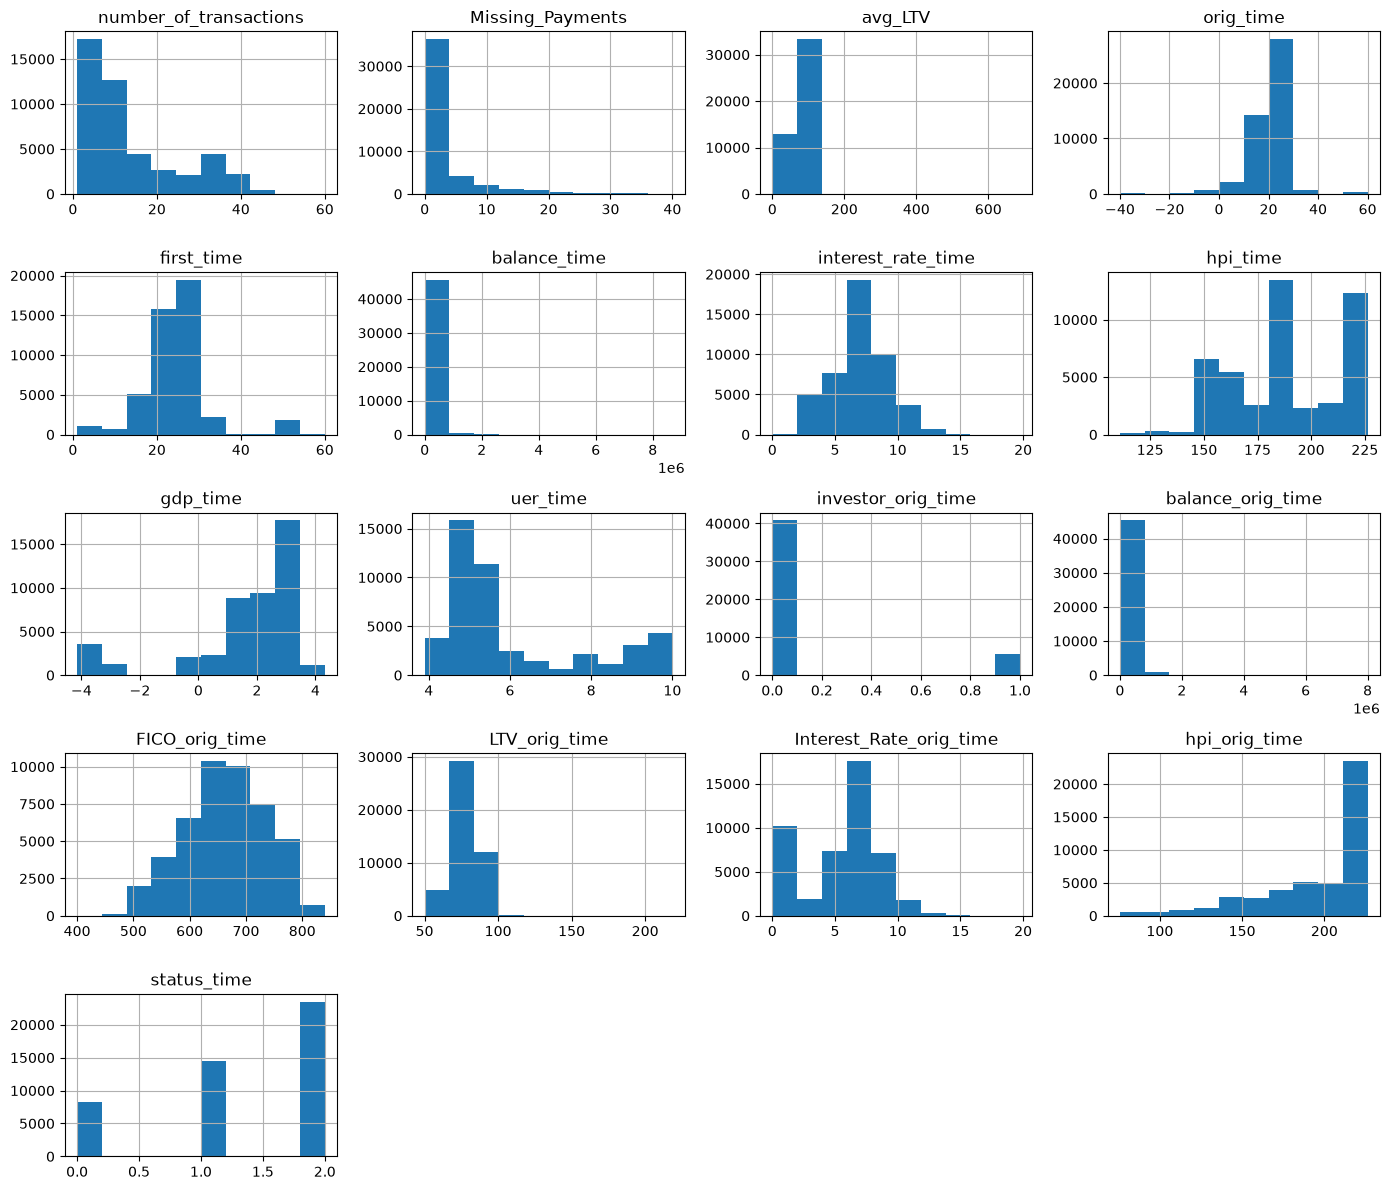

In [13]:
updated_numerical = mortgage_transformed.select_dtypes(include=[np.number]).drop(columns=["id"])
updated_numerical.hist(figsize=(14, 12))
plt.tight_layout()
plt.show()

### Interest rate type distribution

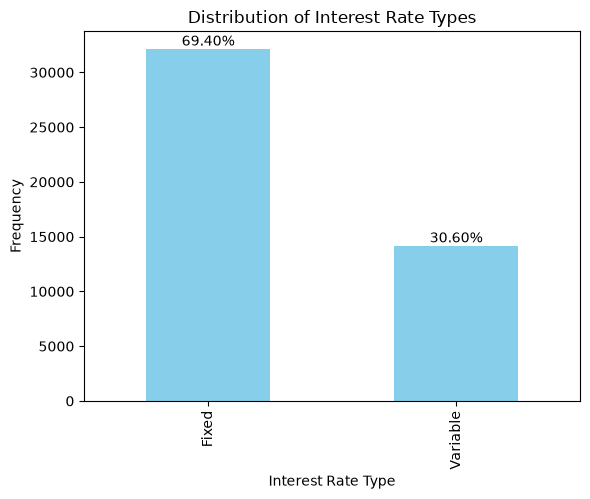

In [14]:
interest_rate_counts = mortgage_transformed["interest_rate_type"].value_counts()
percentages = 100 * interest_rate_counts / interest_rate_counts.sum()
ax = interest_rate_counts.plot(kind="bar", color="skyblue",
                               title="Distribution of Interest Rate Types")
for i, (count, pct) in enumerate(zip(interest_rate_counts, percentages)):
    ax.text(i, count, f"{pct:.2f}%", ha="center", va="bottom")
ax.set_xlabel("Interest Rate Type"); ax.set_ylabel("Frequency")
plt.show()

## Data Analysis — Categorical Attributes

### Property types of borrowers

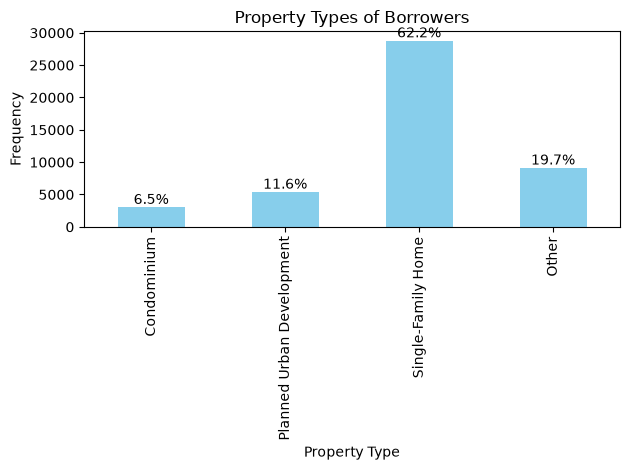

In [15]:
property_counts = mortgage_transformed["Property_Type"].value_counts().reindex(
    ["Condominium", "Planned Urban Development", "Single-Family Home", "Other"]
)
property_pct = (property_counts / property_counts.sum() * 100).round(1)
ax = property_counts.plot(kind="bar", color="skyblue", title="Property Types of Borrowers")
for i, (count, pct) in enumerate(zip(property_counts, property_pct)):
    ax.text(i, count, f"{pct}%", ha="center", va="bottom")
ax.set_xlabel("Property Type"); ax.set_ylabel("Frequency")
plt.tight_layout(); plt.show()

### Investor borrower at origination time

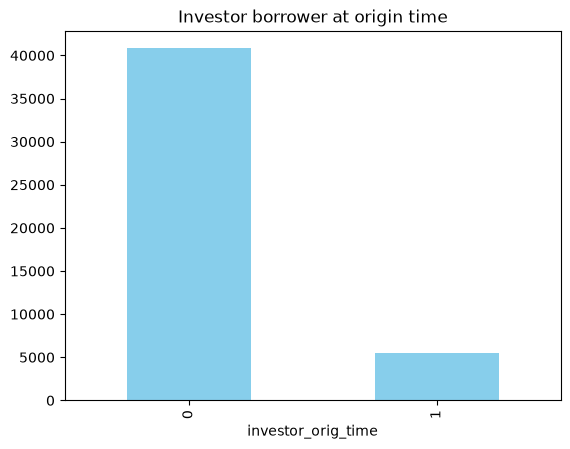

In [16]:
mortgage_transformed["investor_orig_time"].value_counts().plot(
    kind="bar", color="skyblue", title="Investor borrower at origin time")
plt.show()

### Target variable

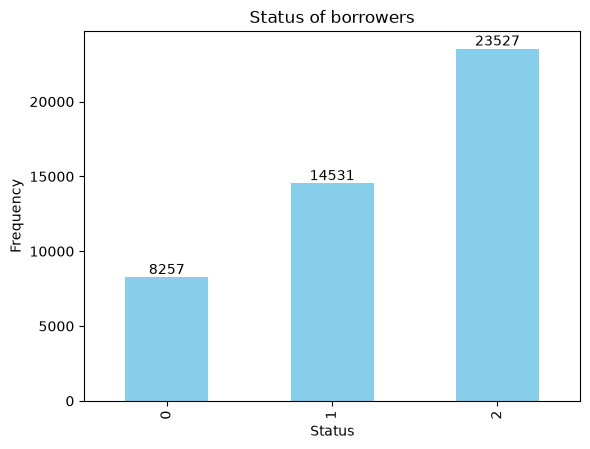

In [17]:
status_table = mortgage_transformed["status_time"].value_counts().sort_index()
ax = status_table.plot(kind="bar", color="skyblue", title="Status of borrowers")
for i, v in enumerate(status_table):
    ax.text(i, v, str(v), ha="center", va="bottom")
ax.set_xlabel("Status"); ax.set_ylabel("Frequency")
plt.show()

## Correlation Analysis (Spearman)

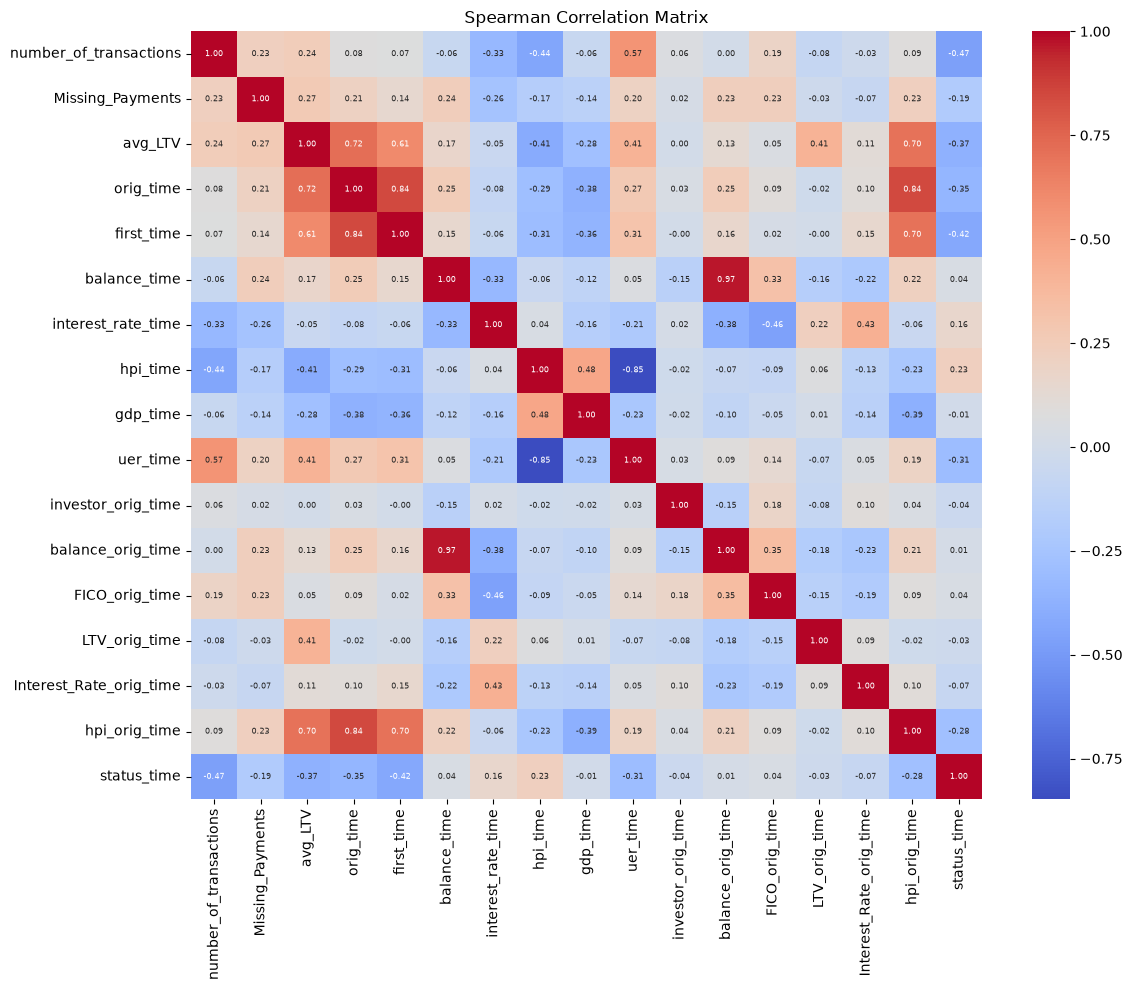

                         number_of_transactions  Missing_Payments   avg_LTV  \
number_of_transactions                 1.000000          0.227404  0.243767   
Missing_Payments                       0.227404          1.000000  0.268446   
avg_LTV                                0.243767          0.268446  1.000000   
orig_time                              0.080972          0.208297  0.718292   
first_time                             0.074604          0.143936  0.610020   
balance_time                          -0.061357          0.240800  0.165757   
interest_rate_time                    -0.334756         -0.260574 -0.054135   
hpi_time                              -0.442200         -0.171469 -0.414613   
gdp_time                              -0.061479         -0.140173 -0.278298   
uer_time                               0.566613          0.199770  0.412173   
investor_orig_time                     0.058976          0.024491  0.003013   
balance_orig_time                      0.000767     

In [18]:
correlation_matrix = updated_numerical.corr(method="spearman")
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            annot_kws={"size": 6})
plt.title("Spearman Correlation Matrix")
plt.tight_layout(); plt.show()
print(correlation_matrix)

## Feature Selection — Backward Stepwise (AIC), equivalent of R step()

In [19]:
def backward_stepwise_aic(df, target, verbose=True):
    """Backward elimination minimizing AIC using statsmodels OLS
    (mirrors R's step(glm(..., family='gaussian'), direction='backward'))."""
    remaining = [c for c in df.columns if c != target]
    current_aic = sm.OLS(df[target], sm.add_constant(df[remaining])).fit().aic
    improved = True
    while improved and len(remaining) > 1:
        improved = False
        aic_candidates = []
        for col in remaining:
            trial = [c for c in remaining if c != col]
            aic = sm.OLS(df[target], sm.add_constant(df[trial])).fit().aic
            aic_candidates.append((aic, col))
        aic_candidates.sort()
        best_aic, worst_col = aic_candidates[0]
        if best_aic < current_aic:
            remaining.remove(worst_col)
            current_aic = best_aic
            improved = True
            if verbose:
                print(f"Dropped {worst_col:35s} AIC = {current_aic:.2f}")
    return remaining

stepwise_df = pd.get_dummies(
    mortgage_transformed.drop(columns=["id"]),
    columns=["Property_Type", "interest_rate_type"], drop_first=False, dtype=float,
).dropna()
selected_features = backward_stepwise_aic(stepwise_df, target="status_time")
print("\nSelected features (backward stepwise):", selected_features)


Selected features (backward stepwise): ['number_of_transactions', 'Missing_Payments', 'avg_LTV', 'orig_time', 'first_time', 'balance_time', 'interest_rate_time', 'hpi_time', 'gdp_time', 'uer_time', 'investor_orig_time', 'balance_orig_time', 'FICO_orig_time', 'LTV_orig_time', 'Interest_Rate_orig_time', 'hpi_orig_time', 'Property_Type_Condominium', 'Property_Type_Other', 'Property_Type_Planned Urban Development', 'Property_Type_Single-Family Home', 'interest_rate_type_Fixed', 'interest_rate_type_Variable']


## Dummy variables for categorical columns

In [20]:
mortgage_transformed = pd.get_dummies(
    mortgage_transformed, columns=["Property_Type"], dtype=int
)
mortgage_transformed["interest_rate_type"] = (
    mortgage_transformed["interest_rate_type"].map({"Fixed": 0, "Variable": 1})
)

# Split: resolved loans (status 1 = default, 2 = paidoff) vs. active borrowers (holdout)
paidoff_default = mortgage_transformed[mortgage_transformed["status_time"].isin([1, 2])].copy()
holdout_df = mortgage_transformed[~mortgage_transformed["status_time"].isin([1, 2])].copy()

print(paidoff_default["status_time"].value_counts())
print(holdout_df["status_time"].value_counts())

# Recode target: default (1) -> 0, paidoff (2) -> 1
paidoff_default["status_time"] = paidoff_default["status_time"].map({1: 0, 2: 1})
print(paidoff_default["status_time"].value_counts())

LABELS = {0: "Default", 1: "Paidoff"}

status_time
2    23527
1    14531
Name: count, dtype: int64
status_time
0    8257
Name: count, dtype: int64
status_time
1    23527
0    14531
Name: count, dtype: int64


## Data Partitioning — Train (60%) / Validation (40%); active borrowers = holdout

Train: 22834 | Validation: 15224 | Holdout: 8257


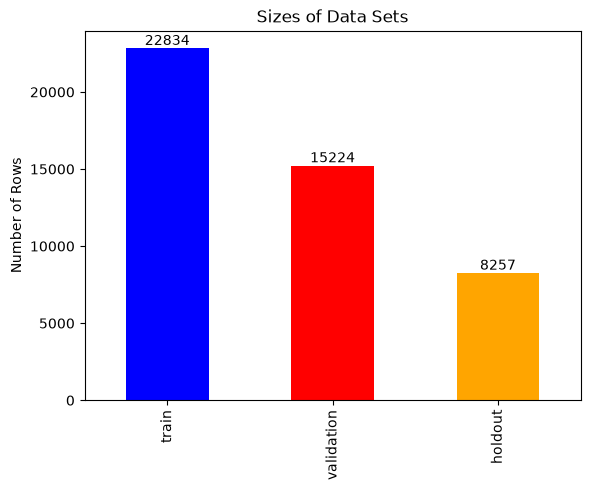

In [21]:
train_data1, validation_data1 = train_test_split(
    paidoff_default, train_size=0.6, random_state=RANDOM_SEED
)
print("Train:", len(train_data1), "| Validation:", len(validation_data1),
      "| Holdout:", len(holdout_df))

set_sizes = pd.Series({"train": len(train_data1),
                       "validation": len(validation_data1),
                       "holdout": len(holdout_df)})
ax = set_sizes.plot(kind="bar", color=["blue", "red", "orange"],
                    title="Sizes of Data Sets")
for i, v in enumerate(set_sizes):
    ax.text(i, v, str(v), ha="center", va="bottom")
ax.set_ylabel("Number of Rows")
plt.show()

FEATURES_G1 = [c for c in paidoff_default.columns if c not in ("id", "status_time")]

def evaluate(y_true, y_pred, title):
    """Print a confusion matrix and metrics (equivalent of caret::confusionMatrix)."""
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n===== {title} =====")
    print(pd.DataFrame(cm,
                       index=[f"Actual {LABELS[i]}" for i in (0, 1)],
                       columns=[f"Pred {LABELS[i]}" for i in (0, 1)]))
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred, target_names=[LABELS[0], LABELS[1]]))

## Goal 1 — Active borrowers (full feature set)

### Model 1: Logistic Regression

In [22]:
logistic_model = LogisticRegression(max_iter=5000)
logistic_model.fit(train_data1[FEATURES_G1], train_data1["status_time"])

val_prob = logistic_model.predict_proba(validation_data1[FEATURES_G1])[:, 1]
val_pred = (val_prob > 0.5).astype(int)
evaluate(validation_data1["status_time"], val_pred,
         "Goal 1 — Logistic Regression (validation)")


===== Goal 1 — Logistic Regression (validation) =====
                Pred Default  Pred Paidoff
Actual Default          3883          1972
Actual Paidoff          1469          7900
Accuracy: 0.7740
              precision    recall  f1-score   support

     Default       0.73      0.66      0.69      5855
     Paidoff       0.80      0.84      0.82      9369

    accuracy                           0.77     15224
   macro avg       0.76      0.75      0.76     15224
weighted avg       0.77      0.77      0.77     15224



c:\Users\sriva\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Model 2: Classification Tree

In [23]:
tree_model = DecisionTreeClassifier(random_state=RANDOM_SEED)
tree_model.fit(train_data1[FEATURES_G1], train_data1["status_time"])
tree_pred = tree_model.predict(validation_data1[FEATURES_G1])
evaluate(validation_data1["status_time"], tree_pred,
         "Goal 1 — Classification Tree (validation)")


===== Goal 1 — Classification Tree (validation) =====
                Pred Default  Pred Paidoff
Actual Default          3807          2048
Actual Paidoff          2048          7321
Accuracy: 0.7310
              precision    recall  f1-score   support

     Default       0.65      0.65      0.65      5855
     Paidoff       0.78      0.78      0.78      9369

    accuracy                           0.73     15224
   macro avg       0.72      0.72      0.72     15224
weighted avg       0.73      0.73      0.73     15224



## Goal 2 — New customers (origination-time features only: drop behavioral cols)

In [24]:
behavioral_cols = paidoff_default.columns[:10]  # id + behavioral/time-varying block
paidoff_default_update = paidoff_default.drop(columns=behavioral_cols)
print(paidoff_default_update.head())

FEATURES_G2 = [c for c in paidoff_default_update.columns if c != "status_time"]
train_data2, validation_data2 = train_test_split(
    paidoff_default_update, train_size=0.7, random_state=RANDOM_SEED,
    stratify=paidoff_default_update["status_time"],
)
print(train_data2["status_time"].value_counts())
print(validation_data2["status_time"].value_counts())

   gdp_time  uer_time  investor_orig_time  balance_orig_time  FICO_orig_time  \
0  2.715903       8.3                   0            45000.0             715   
1  2.151365       4.7                   0           107200.0             558   
2  1.692969       4.5                   0            48600.0             680   
4  2.361722       4.4                   0            52800.0             527   
5  1.717053       6.6                   0           212000.0             670   

   LTV_orig_time  Interest_Rate_orig_time  hpi_orig_time  status_time  \
0           69.4                    9.200          87.03            0   
1           80.0                    7.680         186.91            1   
2           83.6                    8.750          89.58            1   
4           80.0                    9.155         186.91            1   
5           80.0                    6.580         191.42            0   

   Property_Type_Condominium  Property_Type_Other  \
0                          

### Logistic Regression for Goal 2

In [25]:
logistic_model_2 = LogisticRegression(max_iter=5000)
logistic_model_2.fit(train_data2[FEATURES_G2], train_data2["status_time"])
val_pred_2 = (logistic_model_2.predict_proba(validation_data2[FEATURES_G2])[:, 1] > 0.5).astype(int)
evaluate(validation_data2["status_time"], val_pred_2,
         "Goal 2 — Logistic Regression (validation)")


===== Goal 2 — Logistic Regression (validation) =====
                Pred Default  Pred Paidoff
Actual Default          2441          1919
Actual Paidoff          1117          5941
Accuracy: 0.7341
              precision    recall  f1-score   support

     Default       0.69      0.56      0.62      4360
     Paidoff       0.76      0.84      0.80      7058

    accuracy                           0.73     11418
   macro avg       0.72      0.70      0.71     11418
weighted avg       0.73      0.73      0.73     11418



c:\Users\sriva\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Classification Tree for Goal 2

In [26]:
tree_model_2 = DecisionTreeClassifier(random_state=RANDOM_SEED)
tree_model_2.fit(train_data2[FEATURES_G2], train_data2["status_time"])
tree_pred_2 = tree_model_2.predict(validation_data2[FEATURES_G2])
evaluate(validation_data2["status_time"], tree_pred_2,
         "Goal 2 — Classification Tree (validation)")


===== Goal 2 — Classification Tree (validation) =====
                Pred Default  Pred Paidoff
Actual Default          2691          1669
Actual Paidoff          1800          5258
Accuracy: 0.6962
              precision    recall  f1-score   support

     Default       0.60      0.62      0.61      4360
     Paidoff       0.76      0.74      0.75      7058

    accuracy                           0.70     11418
   macro avg       0.68      0.68      0.68     11418
weighted avg       0.70      0.70      0.70     11418



## Holdout scoring — active borrowers (Goal 1 model)


Holdout predictions (Goal 1):
Paidoff    5879
Default    2378
Name: count, dtype: int64


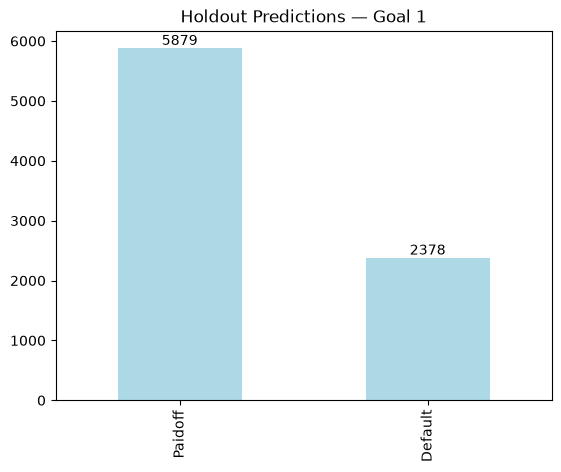

In [27]:
holdout_pred = (logistic_model.predict_proba(holdout_df[FEATURES_G1])[:, 1] > 0.5).astype(int)
holdout_counts = pd.Series(holdout_pred).map(LABELS).value_counts()
print("\nHoldout predictions (Goal 1):")
print(holdout_counts)
ax = holdout_counts.plot(kind="bar", color="lightblue", title="Holdout Predictions — Goal 1")
for i, v in enumerate(holdout_counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.show()

## Holdout scoring — new-customer model (Goal 2 model)


Holdout predictions (Goal 2):
Paidoff    7221
Default    1036
Name: count, dtype: int64


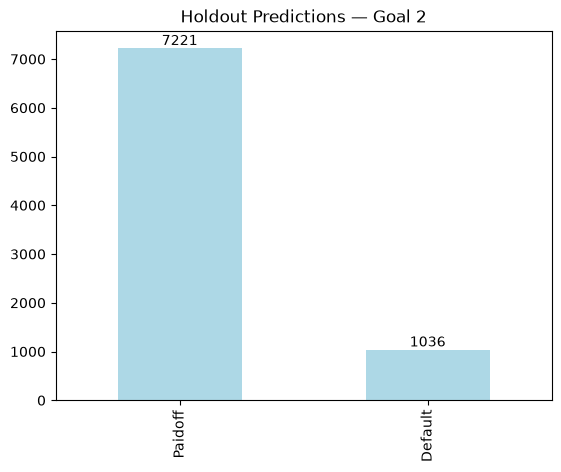

In [28]:
holdout_data2 = holdout_df[FEATURES_G2]
holdout_pred_2 = (logistic_model_2.predict_proba(holdout_data2)[:, 1] > 0.5).astype(int)
holdout_counts_2 = pd.Series(holdout_pred_2).map(LABELS).value_counts()
print("\nHoldout predictions (Goal 2):")
print(holdout_counts_2)
ax = holdout_counts_2.plot(kind="bar", color="lightblue", title="Holdout Predictions — Goal 2")
for i, v in enumerate(holdout_counts_2):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.show()